# Proyecto Final — Predicción del Flujo de Caja
Vyena Teixeira dos Santos

## 1. Formulación del problema

El objetivo del proyecto es predecir los ingresos de caja futuros de una empresa a partir de información histórica de ventas y pagos.

La empresa no trabaja necesariamente con fechas de pago previamente acordadas para todos sus clientes, por lo que existe incertidumbre respecto al momento en que las ventas realizadas se convierten efectivamente en entradas de efectivo.

El problema se formula como una tarea de **regresión supervisada**, donde:

- **Unidad de observación:** período de tiempo agregado.
- **Target:** flujo de caja recibido en un período futuro.
- **Features:** información disponible antes de la fecha de predicción, como ventas históricas, pagos recibidos, saldos pendientes y variables temporales.
- **Objetivo de negocio:** anticipar las entradas de efectivo para mejorar la planificación de liquidez y la toma de decisiones financieras.

### Liberías

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## 1. Preparación y exploración de los datos

### Carga de los datos

In [48]:
ruta_ventas = "data/raw/rev_ventas_diarias_2023_jul.2026.xlsx"
ruta_pagos = "data/raw/rev_pagos_recibidos_2023_jul.2026.xlsx"

df_ventas = pd.read_excel(ruta_ventas)
df_pagos = pd.read_excel(ruta_pagos)

print("Ventas:", df_ventas.shape)
print("Pagos:", df_pagos.shape)

print("\nColumnas ventas:")
print(df_ventas.columns.tolist())

print("\nColumnas pagos:")
print(df_pagos.columns.tolist())

Ventas: (258160, 13)
Pagos: (145512, 13)

Columnas ventas:
['Fecha\nVenta', 'Fecha\nTour', 'Editar', 'ID', 'Estado', 'Vendedor', 'Nombre', 'Telefono', 'Tour', 'PAX\nAdulto', 'PAX\nNiño', 'Monto Total', 'VF']

Columnas pagos:
['ID', 'Unnamed: 1', 'Data', 'Voucher', 'Autor', 'Cliente', 'Estado', 'Monto', 'Forma de Pago', 'Obs', 'Fecha', 'Unnamed: 11', 'Unnamed: 12']


### Revisión inicial

In [49]:
display(df_ventas.head())
display(df_pagos.head())

print("\nTipos de datos - ventas:")
print(df_ventas.dtypes)

print("\nTipos de datos - pagos:")
print(df_pagos.dtypes)

print("\nEstados ventas:")
print(df_ventas["Estado"].value_counts(dropna=False))

print("\nEstados pagos:")
print(df_pagos["Estado"].value_counts(dropna=False))

,Fecha\nVenta,Fecha\nTour,Editar,ID,Estado,Vendedor,Nombre,Telefono,Tour,PAX\nAdulto,PAX\nNiño,Monto Total,VF
0,2023-01-01,2023-01-03 00:00:00,NaN,WLC-62207,Reservado,VD Geovanna Casale,Eduardo Dalbem Teles,5.566000e+12,Valparaiso E Vina Del Mar,2,0,60000,NaN
1,2023-01-01,2023-01-04 00:00:00,NaN,WLC-62208,Reservado,VD Geovanna Casale,Eduardo Dalbem Teles,5.566000e+12,Concha Y Toro Marques - Tarde,2,0,100000,NaN
2,2023-01-01,2023-01-02 00:00:00,NaN,WLC-62203,Confirmado,VD Geovanna Casale,Viviane Silva De Lima,5.535991e+12,Valle De La Luna,2,0,70000,NaN
3,2023-01-01,2023-01-05 00:00:00,NaN,WLC-62204,Confirmado,VD Geovanna Casale,Viviane Silva De Lima,5.535991e+12,Piedras Rojas E Lagunas Altiplanicas,2,0,130000,NaN
4,2023-01-01,2023-01-04 00:00:00,NaN,WLC-62205,Reservado,VD Geovanna Casale,Viviane Silva De Lima,5.535991e+12,Geysers El Tatio,2,0,86000,NaN


,ID,Unnamed: 1,Data,Voucher,Autor,Cliente,Estado,Monto,Forma de Pago,Obs,Fecha,Unnamed: 11,Unnamed: 12
0,PAG-25434,NaN,2026-01-01 00:00:00,VF-19621,logingeovanna,Eduardo Dalbem Teles,Pendiente,130000,Transferencia NUBANK,NaN,2023-01-01,01-01,2023-01-01
1,PAG-25433,NaN,2026-01-01 00:00:00,VF-19620,logingeovanna,Viviane Silva De Lima,Pendiente,271700,Transferencia NUBANK,NaN,2023-01-01,01-01,2023-01-01
2,PAG-25426,NaN,2026-01-01 00:00:00,VF-19612,loginmirella,Jorge Antônio Fernandes Da Silva,Pendiente,271000,Transferencia,155,2023-01-01,01-01,2023-01-01
3,PAG-24410,NaN,2026-01-01 00:00:00,VF-18690,loginsulamita,Beatriz Lins Gorgonio Bartolomei,Confirmado,280000,Wise,pagamento Uyuni,2023-01-01,01-01,2023-01-01
4,PAG-25401,NaN,2026-01-01 00:00:00,VF-19383,logmichelemattoso,Reginaldo Vieira,Recaudado,0,Transferencia,NaN,2023-01-01,01-01,2023-01-01



Tipos de datos - ventas:
Fecha\nVenta    datetime64[ns]
Fecha\nTour             object
Editar                 float64
ID                      object
Estado                  object
Vendedor                object
Nombre                  object
Telefono               float64
Tour                    object
PAX\nAdulto              int64
PAX\nNiño                int64
Monto Total              int64
VF                     float64
dtype: object

Tipos de datos - pagos:
ID                       object
Unnamed: 1              float64
Data                     object
Voucher                  object
Autor                    object
Cliente                  object
Estado                   object
Monto                     int64
Forma de Pago            object
Obs                      object
Fecha            datetime64[ns]
Unnamed: 11              object
Unnamed: 12      datetime64[ns]
dtype: object

Estados ventas:
Estado
Reservado     115105
Confirmado    103181
Cancelado      39038
No Show        

### Preparación inicial

In [50]:
# Limpieza de nombres de columnas
df_ventas.columns = df_ventas.columns.str.replace("\n", " ", regex=False).str.strip()
df_pagos.columns = df_pagos.columns.str.strip()

print("Columnas ventas:")
print(df_ventas.columns.tolist())

print("\nColumnas pagos:")
print(df_pagos.columns.tolist())

Columnas ventas:
['Fecha Venta', 'Fecha Tour', 'Editar', 'ID', 'Estado', 'Vendedor', 'Nombre', 'Telefono', 'Tour', 'PAX Adulto', 'PAX Niño', 'Monto Total', 'VF']

Columnas pagos:
['ID', 'Unnamed: 1', 'Data', 'Voucher', 'Autor', 'Cliente', 'Estado', 'Monto', 'Forma de Pago', 'Obs', 'Fecha', 'Unnamed: 11', 'Unnamed: 12']


### Revisión de variables principales

In [51]:
print("Estados de ventas:")
print(df_ventas["Estado"].value_counts(dropna=False).to_string())

print("\nEstados de pagos:")
print(df_pagos["Estado"].value_counts(dropna=False).to_string())

print("\nTipo de Fecha en pagos:")
print(df_pagos["Fecha"].dtype)

print("\nEjemplos de Monto Total:")
print(df_ventas["Monto Total"].head(10).tolist())

print("\nEjemplos de Monto:")
print(df_pagos["Monto"].head(10).tolist())

Estados de ventas:
Estado
Reservado     115105
Confirmado    103181
Cancelado      39038
No Show          708
Realizado        128

Estados de pagos:
Estado
Confirmado    103918
Pendiente      19496
Recaudado      11662
Pagado          9854
Invalido         582

Tipo de Fecha en pagos:
datetime64[ns]

Ejemplos de Monto Total:
[60000, 100000, 70000, 130000, 86000, -14300, 84000, 195000, 90000, 64000]

Ejemplos de Monto:
[130000, 271700, 271000, 280000, 0, 0, 196000, 100000, 168800, 44000]


### Revisión de pagos válidos

In [52]:
# Se excluyen únicamente los registros inválidos
df_pagos_validos = df_pagos[df_pagos["Estado"] != "Invalido"].copy()

# Identificación del tipo de movimiento según el ID
df_pagos_validos["Prefijo"] = (
    df_pagos_validos["ID"]
    .astype(str)
    .str[:3]
    .str.upper()
)

print(df_pagos_validos["Prefijo"].value_counts())

print("\nResumen por tipo de movimiento:")
print(
    df_pagos_validos.groupby("Prefijo")["Monto"]
    .agg(["count", "sum", "min", "max"])
)

Prefijo
PAG    134477
REE     10453
Name: count, dtype: int64

Resumen por tipo de movimiento:
          count          sum      min      max
Prefijo                                       
PAG      134477  20204933199        0  7127206
REE       10453  -1049280244 -1555004        0


## 2. Construcción del flujo de caja diario

### Flujo de caja neto por día

In [53]:
flujo_diario = (
    df_pagos_validos
    .groupby("Fecha", as_index=False)["Monto"]
    .sum()
    .rename(columns={"Monto": "Flujo_Caja"})
)

display(flujo_diario.head())

print("Período:", flujo_diario["Fecha"].min(), "a", flujo_diario["Fecha"].max())
print("Días con movimientos:", flujo_diario["Fecha"].nunique())

,Fecha,Flujo_Caja
0,2023-01-01,3568020
1,2023-01-02,15283016
2,2023-01-03,9529004
3,2023-01-04,11291093
4,2023-01-05,10427719


Período: 2023-01-01 00:00:00 a 2026-07-31 00:00:00
Días con movimientos: 1308


### Verificación de continuidad temporal

In [63]:
fechas_completas = pd.date_range(
    start=flujo_diario["Fecha"].min(),
    end=flujo_diario["Fecha"].max(),
    freq="D"
)

print("Días esperados:", len(fechas_completas))
print("Días observados:", flujo_diario["Fecha"].nunique())
print("Días faltantes:", len(fechas_completas) - flujo_diario["Fecha"].nunique())

Días esperados: 1308
Días observados: 1308
Días faltantes: 0


### Evolución del flujo de caja

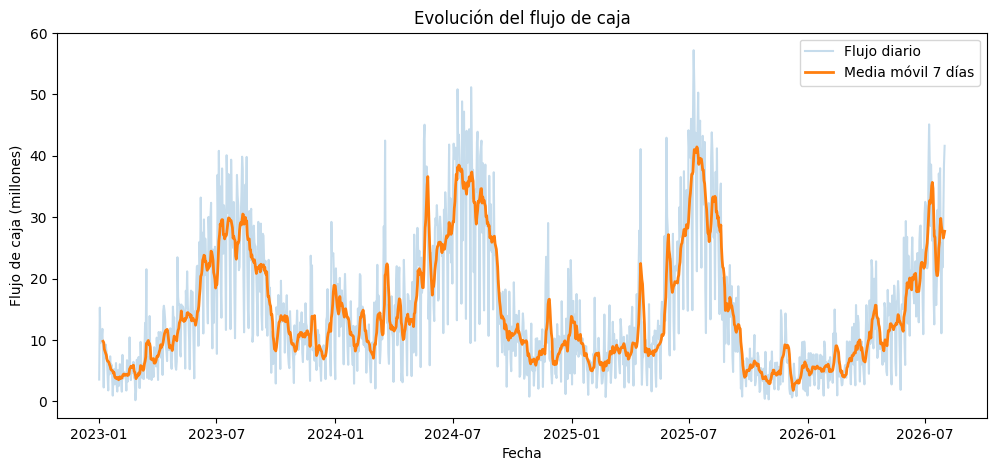

In [58]:
# Media móvil de 7 días
flujo_diario["Media_7d"] = (
    flujo_diario["Flujo_Caja"]
    .rolling(window=7)
    .mean()
)
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 5))

plt.plot(
    flujo_diario["Fecha"],
    flujo_diario["Flujo_Caja"],
    alpha=0.25,
    label="Flujo diario"
)

plt.plot(
    flujo_diario["Fecha"],
    flujo_diario["Media_7d"],
    linewidth=2,
    label="Media móvil 7 días"
)

plt.title("Evolución del flujo de caja")
plt.xlabel("Fecha")
plt.ylabel("Flujo de caja (millones)")
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1_000_000:.0f}")
)

plt.legend()
plt.show()

## 3. Construcción de las ventas diarias

### Revisión de estados de venta

In [60]:
# Conversión del monto de venta a formato numérico
df_ventas["Monto_Total_Num"] = pd.to_numeric(
    df_ventas["Monto Total"],
    errors="coerce"
)

resumen_estados = (
    df_ventas
    .groupby("Estado")["Monto_Total_Num"]
    .agg(["count", "sum", "mean"])
)

display(resumen_estados)

print(
    "Montos no convertidos:",
    df_ventas["Monto_Total_Num"].isna().sum()
)

,count,sum,mean
Estado,,,
Cancelado,39038,3849532550,98609.881398
Confirmado,103181,11187072887,108421.830444
No Show,708,56703264,80089.355932
Realizado,128,11954000,93390.625000
Reservado,115105,9015836011,78327.057999


Montos no convertidos: 0


### Agregación diaria de ventas

In [62]:
estados_validos = [
    "Confirmado",
    "Reservado",
    "No Show",
    "Realizado"
]

df_ventas_validas = df_ventas[
    df_ventas["Estado"].isin(estados_validos)
].copy()

ventas_diarias = (
    df_ventas_validas
    .groupby("Fecha Venta", as_index=False)["Monto_Total_Num"]
    .sum()
    .rename(columns={
        "Fecha Venta": "Fecha",
        "Monto_Total_Num": "Ventas"
    })
)

display(ventas_diarias.head())

print("Período:", ventas_diarias["Fecha"].min(), "a", ventas_diarias["Fecha"].max())
print("Días con ventas:", ventas_diarias["Fecha"].nunique())

,Fecha,Ventas
0,2023-01-01,4155100
1,2023-01-02,9906730
2,2023-01-03,7729513
3,2023-01-04,9827000
4,2023-01-05,9991140


Período: 2023-01-01 00:00:00 a 2026-07-31 00:00:00
Días con ventas: 1308


## 4. Integración de ventas y flujo de caja

In [64]:
df_diario = pd.merge(
    ventas_diarias,
    flujo_diario[["Fecha", "Flujo_Caja"]],
    on="Fecha",
    how="inner"
)

display(df_diario.head())

print("Dimensión:", df_diario.shape)
print("Período:", df_diario["Fecha"].min(), "a", df_diario["Fecha"].max())

,Fecha,Ventas,Flujo_Caja
0,2023-01-01,4155100,3568020
1,2023-01-02,9906730,15283016
2,2023-01-03,7729513,9529004
3,2023-01-04,9827000,11291093
4,2023-01-05,9991140,10427719


Dimensión: (1308, 3)
Período: 2023-01-01 00:00:00 a 2026-07-31 00:00:00


## 5. Definición del target y horizonte de predicción

El objetivo es predecir el flujo de caja acumulado de los próximos 7 días.

**Momento de predicción:** la estimación se realiza al inicio del día `t`, utilizando únicamente información disponible hasta el cierre del día `t-1`.

Por lo tanto, el target corresponde al flujo de caja acumulado desde el día `t` hasta el día `t+6`. De esta forma, ninguna información del período que se intenta predecir se utiliza como variable explicativa, evitando data leakage.

In [71]:
# Flujo de caja acumulado desde t hasta t+6
df_diario["Target_7d"] = sum(
    df_diario["Flujo_Caja"].shift(-i)
    for i in range(0, 7)
)

display(
    df_diario[
        ["Fecha", "Ventas", "Flujo_Caja", "Target_7d"]
    ].head(10)
)

,Fecha,Ventas,Flujo_Caja,Target_7d
0,2023-01-01,4155100,3568020,68560146.0
1,2023-01-02,9906730,15283016,67271574.0
2,2023-01-03,7729513,9529004,59469450.0
3,2023-01-04,9827000,11291093,57047284.0
4,2023-01-05,9991140,10427719,55018545.0
5,2023-01-06,9851240,11820494,53050789.0
6,2023-01-07,7047700,6640800,48202070.0
7,2023-01-08,3924100,2279448,45997647.0
8,2023-01-09,9278348,7480892,45513709.0
9,2023-01-10,10715730,7106838,44642028.0


## 6. Ingeniería de variables

### Variables de calendario

In [72]:
df_diario["Dia_Semana"] = df_diario["Fecha"].dt.dayofweek
df_diario["Mes"] = df_diario["Fecha"].dt.month

### Lags

In [73]:
df_diario["Ventas_Lag1"] = df_diario["Ventas"].shift(1)
df_diario["Ventas_Lag7"] = df_diario["Ventas"].shift(7)

df_diario["Flujo_Lag1"] = df_diario["Flujo_Caja"].shift(1)
df_diario["Flujo_Lag7"] = df_diario["Flujo_Caja"].shift(7)

### Medias móviles

In [74]:
df_diario["Ventas_Media7"] = (
    df_diario["Ventas"]
    .shift(1)
    .rolling(7)
    .mean()
)

df_diario["Flujo_Media7"] = (
    df_diario["Flujo_Caja"]
    .shift(1)
    .rolling(7)
    .mean()
)

df_diario["Ventas_Media30"] = (
    df_diario["Ventas"]
    .shift(1)
    .rolling(30)
    .mean()
)

df_diario["Flujo_Media30"] = (
    df_diario["Flujo_Caja"]
    .shift(1)
    .rolling(30)
    .mean()
)

### Revisión de variables creadas

In [77]:
columnas_revision = [
    "Fecha",
    "Ventas",
    "Flujo_Caja",
    "Dia_Semana",
    "Mes",
    "Ventas_Lag1",
    "Ventas_Lag7",
    "Flujo_Lag1",
    "Flujo_Lag7",
    "Ventas_Media7",
    "Flujo_Media7",
    "Ventas_Media30",
    "Flujo_Media30",
    "Target_7d"
]

display(df_diario[columnas_revision].head(35))
print("Valores nulos por variable:")
print(df_diario[columnas_revision].isna().sum())

print(df_diario[columnas_revision].isna().sum())

,Fecha,Ventas,Flujo_Caja,Dia_Semana,Mes,Ventas_Lag1,Ventas_Lag7,Flujo_Lag1,Flujo_Lag7,Ventas_Media7,Flujo_Media7,Ventas_Media30,Flujo_Media30,Target_7d
0,2023-01-01,4155100,3568020,6,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68560146.0
1,2023-01-02,9906730,15283016,0,1,4155100.0,NaN,3568020.0,NaN,NaN,NaN,NaN,NaN,67271574.0
2,2023-01-03,7729513,9529004,1,1,9906730.0,NaN,15283016.0,NaN,NaN,NaN,NaN,NaN,59469450.0
3,2023-01-04,9827000,11291093,2,1,7729513.0,NaN,9529004.0,NaN,NaN,NaN,NaN,NaN,57047284.0
4,2023-01-05,9991140,10427719,3,1,9827000.0,NaN,11291093.0,NaN,NaN,NaN,NaN,NaN,55018545.0
5,2023-01-06,9851240,11820494,4,1,9991140.0,NaN,10427719.0,NaN,NaN,NaN,NaN,NaN,53050789.0
6,2023-01-07,7047700,6640800,5,1,9851240.0,NaN,11820494.0,NaN,NaN,NaN,NaN,NaN,48202070.0
7,2023-01-08,3924100,2279448,6,1,7047700.0,4155100.0,6640800.0,3568020.0,8.358346e+06,9.794307e+06,NaN,NaN,45997647.0
8,2023-01-09,9278348,7480892,0,1,3924100.0,9906730.0,2279448.0,15283016.0,8.325346e+06,9.610225e+06,NaN,NaN,45513709.0
9,2023-01-10,10715730,7106838,1,1,9278348.0,7729513.0,7480892.0,9529004.0,8.235577e+06,8.495636e+06,NaN,NaN,44642028.0


Valores nulos por variable:
Fecha              0
Ventas             0
Flujo_Caja         0
Dia_Semana         0
Mes                0
Ventas_Lag1        1
Ventas_Lag7        7
Flujo_Lag1         1
Flujo_Lag7         7
Ventas_Media7      7
Flujo_Media7       7
Ventas_Media30    30
Flujo_Media30     30
Target_7d          6
dtype: int64
Fecha              0
Ventas             0
Flujo_Caja         0
Dia_Semana         0
Mes                0
Ventas_Lag1        1
Ventas_Lag7        7
Flujo_Lag1         1
Flujo_Lag7         7
Ventas_Media7      7
Flujo_Media7       7
Ventas_Media30    30
Flujo_Media30     30
Target_7d          6
dtype: int64


## 7. Preparación de los datos para modelado

Se seleccionan como variables explicativas únicamente aquellas disponibles al inicio del día `t`, es decir, información histórica hasta `t-1` y variables de calendario conocidas previamente.

Las observaciones con valores faltantes generados por los lags y medias móviles son eliminadas antes del modelado. El `Target_7d` corresponde al flujo de caja acumulado desde `t` hasta `t+6`.

In [80]:
features = [
    "Dia_Semana",
    "Mes",
    "Ventas_Lag1",
    "Ventas_Lag7",
    "Flujo_Lag1",
    "Flujo_Lag7",
    "Ventas_Media7",
    "Flujo_Media7",
    "Ventas_Media30",
    "Flujo_Media30"
]

# Eliminación de observaciones incompletas
df_modelo = df_diario.dropna(
    subset=features + ["Target_7d"]
).copy()

# Separación entre variables explicativas y target
X = df_modelo[features]
y = df_modelo["Target_7d"]

print("X:", X.shape)
print("y:", y.shape)

X: (1272, 10)
y: (1272,)


## 8. División temporal de los datos

Los datos se dividen respetando el orden temporal. Se utiliza el período 2023-2025 para entrenamiento y 2026 como período fuera de muestra.

Debido a que el target considera una ventana de 7 días, se evita que las observaciones de entrenamiento incluyan en su target información perteneciente al período de prueba.

In [81]:
# Fecha de inicio del período de prueba
fecha_test = pd.Timestamp("2026-01-01")

# El último target de entrenamiento debe terminar antes del test
fecha_fin_train = fecha_test - pd.Timedelta(days=7)

train = df_modelo[df_modelo["Fecha"] <= fecha_fin_train].copy()
test = df_modelo[df_modelo["Fecha"] >= fecha_test].copy()

X_train = train[features]
y_train = train["Target_7d"]

X_test = test[features]
y_test = test["Target_7d"]

print("Entrenamiento:", train["Fecha"].min(), "a", train["Fecha"].max())
print("Test:", test["Fecha"].min(), "a", test["Fecha"].max())

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Entrenamiento: 2023-01-31 00:00:00 a 2025-12-25 00:00:00
Test: 2026-01-01 00:00:00 a 2026-07-25 00:00:00
X_train: (1060, 10)
X_test: (206, 10)


## 9. Validación temporal walk-forward

Para evaluar los modelos se utiliza una validación temporal tipo walk-forward, respetando el orden cronológico de los datos.

En cada fold, el modelo se entrena únicamente con información pasada y se valida sobre un período posterior. Además, se incorpora un `gap` de 6 días para evitar que el horizonte de 7 días del target de entrenamiento se solape con el período de validación.

In [83]:
tscv = TimeSeriesSplit(
    n_splits=5,
    gap=6
)

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    fechas_train = train.iloc[train_idx]["Fecha"]
    fechas_val = train.iloc[val_idx]["Fecha"]

    print(
        f"Fold {i}:",
        f"Train {fechas_train.min().date()} a {fechas_train.max().date()} |",
        f"Validación {fechas_val.min().date()} a {fechas_val.max().date()}"
    )


Fold 1: Train 2023-01-31 a 2023-07-23 | Validación 2023-07-30 a 2024-01-21
Fold 2: Train 2023-01-31 a 2024-01-15 | Validación 2024-01-22 a 2024-07-15
Fold 3: Train 2023-01-31 a 2024-07-09 | Validación 2024-07-16 a 2025-01-07
Fold 4: Train 2023-01-31 a 2025-01-01 | Validación 2025-01-08 a 2025-07-02
Fold 5: Train 2023-01-31 a 2025-06-26 | Validación 2025-07-03 a 2025-12-25


## 10. Modelo baseline: Ridge

Se utiliza Ridge como modelo lineal de referencia. Dado que este modelo es sensible a la escala de las variables, se utiliza un `Pipeline` con estandarización y regresión Ridge.

La estandarización se ajusta nuevamente dentro de cada fold de la validación temporal, utilizando únicamente los datos de entrenamiento correspondientes. De esta forma se evita incorporar información futura durante el preprocesamiento.

In [90]:
# Pipeline de escalamiento y modelo Ridge
modelo_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

In [91]:
resultados_ridge = []

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]

    modelo_ridge.fit(X_fold_train, y_fold_train)

    pred_val = modelo_ridge.predict(X_fold_val)

    mae = mean_absolute_error(y_fold_val, pred_val)
    rmse = np.sqrt(mean_squared_error(y_fold_val, pred_val))

    resultados_ridge.append({
        "Fold": i,
        "MAE": mae,
        "RMSE": rmse
    })

resultados_ridge = pd.DataFrame(resultados_ridge)


print("MAE promedio:", resultados_ridge["MAE"].mean())
print("RMSE promedio:", resultados_ridge["RMSE"].mean())

resultados_ridge["MAE_Millones"] = resultados_ridge["MAE"] / 1_000_000
resultados_ridge["RMSE_Millones"] = resultados_ridge["RMSE"] / 1_000_000

display(
    resultados_ridge[
        ["Fold", "MAE_Millones", "RMSE_Millones"]
    ].round(2)
)

MAE promedio: 36170197.01574206
RMSE promedio: 43204089.60949717


,Fold,MAE_Millones,RMSE_Millones
0,1,97.29,105.42
1,2,29.24,36.24
2,3,17.36,21.99
3,4,19.71,29.02
4,5,17.26,23.35


La validación temporal muestra diferencias relevantes entre los folds. El primer período presenta errores considerablemente mayores, mientras que los folds posteriores muestran una reducción del MAE y RMSE.

Estos resultados corresponden únicamente a la validación dentro del conjunto de entrenamiento y todavía no representan el desempeño final fuera de muestra.

### Ajuste del hiperparámetro alpha

El parámetro `alpha` controla la intensidad de la regularización Ridge. Se comparan diferentes valores utilizando la misma validación temporal walk-forward y se selecciona aquel que presenta el menor MAE promedio.

In [92]:
alphas = [0.01, 0.1, 1, 10, 100, 1000]

resultados_alpha = []

for alpha in alphas:

    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    maes = []
    rmses = []

    for train_idx, val_idx in tscv.split(X_train):

        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]

        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]

        modelo.fit(X_fold_train, y_fold_train)
        pred_val = modelo.predict(X_fold_val)

        maes.append(mean_absolute_error(y_fold_val, pred_val))
        rmses.append(
            np.sqrt(mean_squared_error(y_fold_val, pred_val))
        )

    resultados_alpha.append({
        "Alpha": alpha,
        "MAE": np.mean(maes),
        "RMSE": np.mean(rmses)
    })

resultados_alpha = pd.DataFrame(resultados_alpha)

resultados_alpha["MAE_Millones"] = resultados_alpha["MAE"] / 1_000_000
resultados_alpha["RMSE_Millones"] = resultados_alpha["RMSE"] / 1_000_000

display(
    resultados_alpha[
        ["Alpha", "MAE_Millones", "RMSE_Millones"]
    ].round(2)
)

,Alpha,MAE_Millones,RMSE_Millones
0,0.01,38.19,45.27
1,0.10,37.96,45.04
2,1.00,36.17,43.20
3,10.00,30.30,37.38
4,100.00,25.37,32.70
5,1000.00,28.93,35.75


El ajuste del hiperparámetro `alpha` muestra que la regularización mejora el desempeño del modelo hasta cierto punto. El menor MAE promedio se obtiene con `alpha = 100`, mientras que una regularización excesiva (`alpha = 1000`) vuelve a aumentar el error.

### Ajuste fino del hiperparámetro alpha

La búsqueda inicial permitió identificar que los mejores resultados se encuentran alrededor de `alpha = 100`. Por esta razón, se realiza una segunda búsqueda más detallada en esta región antes de seleccionar el valor definitivo.

In [99]:
alphas_finos = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 300, 400]

resultados_alpha_fino = []

for alpha in alphas_finos:

    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    maes = []
    rmses = []

    for train_idx, val_idx in tscv.split(X_train):

        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]

        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]

        modelo.fit(X_fold_train, y_fold_train)

        pred_val = modelo.predict(X_fold_val)

        maes.append(
            mean_absolute_error(y_fold_val, pred_val)
        )

        rmses.append(
            np.sqrt(mean_squared_error(y_fold_val, pred_val))
        )

    resultados_alpha_fino.append({
        "Alpha": alpha,
        "MAE": np.mean(maes),
        "RMSE": np.mean(rmses)
    })

resultados_alpha_fino = pd.DataFrame(resultados_alpha_fino)

resultados_alpha_fino["MAE_Millones"] = (
    resultados_alpha_fino["MAE"] / 1_000_000
)

resultados_alpha_fino["RMSE_Millones"] = (
    resultados_alpha_fino["RMSE"] / 1_000_000
)

display(
    resultados_alpha_fino[
        ["Alpha", "MAE_Millones", "RMSE_Millones"]
    ].round(2)
)

,Alpha,MAE_Millones,RMSE_Millones
0,25,27.81,34.98
1,50,26.35,33.61
2,75,25.71,33.02
3,100,25.37,32.70
4,125,25.18,32.52
5,150,25.08,32.42
6,175,25.04,32.36
7,200,25.03,32.35
8,225,25.05,32.36
9,250,25.10,32.39


La búsqueda refinada muestra que el error de validación disminuye progresivamente a medida que aumenta la regularización, alcanzando su menor valor en `alpha = 200`.

A partir de este punto, tanto el MAE como el RMSE comienzan a aumentar ligeramente. Por lo tanto, se selecciona `alpha = 200` como hiperparámetro definitivo del modelo Ridge.

### Revisión de ajuste del modelo

In [100]:
resultados_ajuste = []

for alpha in alphas_finos:

    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    maes_train = []
    maes_val = []

    for train_idx, val_idx in tscv.split(X_train):

        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]

        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]

        modelo.fit(X_fold_train, y_fold_train)

        pred_train = modelo.predict(X_fold_train)
        pred_val = modelo.predict(X_fold_val)

        maes_train.append(
            mean_absolute_error(y_fold_train, pred_train)
        )

        maes_val.append(
            mean_absolute_error(y_fold_val, pred_val)
        )

    resultados_ajuste.append({
        "Alpha": alpha,
        "MAE_Train": np.mean(maes_train) / 1_000_000,
        "MAE_Validacion": np.mean(maes_val) / 1_000_000
    })

resultados_ajuste = pd.DataFrame(resultados_ajuste)

display(resultados_ajuste.round(2))

,Alpha,MAE_Train,MAE_Validacion
0,25,15.50,27.81
1,50,15.85,26.35
2,75,16.14,25.71
3,100,16.40,25.37
4,125,16.64,25.18
5,150,16.87,25.08
6,175,17.10,25.04
7,200,17.33,25.03
8,225,17.55,25.05
9,250,17.77,25.10


La comparación entre entrenamiento y validación muestra que, al aumentar `alpha`, el error de entrenamiento aumenta gradualmente mientras que el error de validación disminuye hasta alcanzar su mínimo en `alpha = 200`.

Esto indica que la regularización ayuda a reducir el sobreajuste y mejorar la capacidad de generalización del modelo. A partir de `alpha = 200`, el error de validación vuelve a aumentar junto con el error de entrenamiento, lo que sugiere que una regularización mayor comienza a reducir excesivamente la capacidad de ajuste del modelo.

Por lo tanto, se selecciona `alpha = 200` como el mejor equilibrio entre ajuste y generalización dentro de los valores evaluados.

### Modelo Ridge seleccionado

In [101]:
# Modelo Ridge con el mejor alpha
modelo_ridge_final = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=200))
])

modelo_ridge_final.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge(alpha=200))])

## 11. Random Forest

Se utiliza Random Forest como segundo modelo, permitiendo capturar relaciones no lineales entre las variables históricas y el flujo de caja futuro.

A diferencia de Ridge, Random Forest no requiere estandarización de las variables. Su desempeño se evalúa utilizando la misma validación temporal walk-forward para mantener una comparación consistente entre modelos.

In [105]:
modelo_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

resultados_rf = []

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]

    modelo_rf.fit(X_fold_train, y_fold_train)

    pred_train = modelo_rf.predict(X_fold_train)
    pred_val = modelo_rf.predict(X_fold_val)

    mae_train = mean_absolute_error(y_fold_train, pred_train)
    mae_val = mean_absolute_error(y_fold_val, pred_val)
    rmse_val = np.sqrt(
        mean_squared_error(y_fold_val, pred_val)
    )

    resultados_rf.append({
        "Fold": i,
        "MAE_Train": mae_train / 1_000_000,
        "MAE_Validacion": mae_val / 1_000_000,
        "RMSE_Validacion": rmse_val / 1_000_000
    })

resultados_rf = pd.DataFrame(resultados_rf)

display(resultados_rf.round(2))

print(
    "MAE promedio validación:",
    round(resultados_rf["MAE_Validacion"].mean(), 2),
    "millones"
)

,Fold,MAE_Train,MAE_Validacion,RMSE_Validacion
0,1,2.02,21.80,28.69
1,2,2.87,31.11,40.36
2,3,3.59,20.87,26.23
3,4,3.52,25.31,33.92
4,5,3.92,25.99,30.35


MAE promedio validación: 25.01 millones


El modelo Random Forest baseline obtiene un MAE promedio de validación cercano a 25 millones, similar al obtenido por Ridge.

Sin embargo, el MAE de entrenamiento es considerablemente menor que el MAE de validación en todos los folds. Esta diferencia indica que el modelo se ajusta demasiado a los datos de entrenamiento, mostrando señales de overfitting.

Por esta razón, se ajustarán hiperparámetros que controlan la complejidad de los árboles antes de seleccionar el modelo definitivo.

### Ajuste de hiperparámetros

Se evalúan diferentes valores de profundidad máxima y número mínimo de observaciones por hoja. Estos parámetros permiten limitar la complejidad de los árboles y reducir el riesgo de overfitting.

La selección se realiza utilizando el mismo esquema de validación temporal walk-forward y el MAE promedio de validación como criterio principal.

In [107]:
max_depths = [3, 5, 7, 10, None]
min_samples_leafs = [1, 5, 10, 20]

resultados_rf_tuning = []

for depth in max_depths:
    for min_leaf in min_samples_leafs:

        maes_train = []
        maes_val = []
        rmses_val = []

        modelo = RandomForestRegressor(
            n_estimators=300,
            max_depth=depth,
            min_samples_leaf=min_leaf,
            random_state=42,
            n_jobs=-1
        )

        for train_idx, val_idx in tscv.split(X_train):

            X_fold_train = X_train.iloc[train_idx]
            y_fold_train = y_train.iloc[train_idx]

            X_fold_val = X_train.iloc[val_idx]
            y_fold_val = y_train.iloc[val_idx]

            modelo.fit(X_fold_train, y_fold_train)

            pred_train = modelo.predict(X_fold_train)
            pred_val = modelo.predict(X_fold_val)

            maes_train.append(
                mean_absolute_error(y_fold_train, pred_train)
            )

            maes_val.append(
                mean_absolute_error(y_fold_val, pred_val)
            )

            rmses_val.append(
                np.sqrt(mean_squared_error(y_fold_val, pred_val))
            )

        resultados_rf_tuning.append({
            "Max_Depth": depth,
            "Min_Samples_Leaf": min_leaf,
            "MAE_Train": np.mean(maes_train) / 1_000_000,
            "MAE_Validacion": np.mean(maes_val) / 1_000_000,
            "RMSE_Validacion": np.mean(rmses_val) / 1_000_000
        })

resultados_rf_tuning = pd.DataFrame(resultados_rf_tuning)

resultados_rf_tuning = resultados_rf_tuning.sort_values(
    "MAE_Validacion"
)

display(resultados_rf_tuning.round(2))

,Max_Depth,Min_Samples_Leaf,MAE_Train,MAE_Validacion,RMSE_Validacion
6,5.0,10,10.35,23.66,30.41
5,5.0,5,8.97,23.71,30.17
18,NaN,10,9.28,23.91,30.70
14,10.0,10,9.29,23.91,30.70
10,7.0,10,9.53,23.92,30.68
2,3.0,10,12.75,23.99,30.61
4,5.0,1,8.42,24.11,30.59
9,7.0,5,7.24,24.13,30.59
13,10.0,5,6.37,24.18,30.71
17,NaN,5,6.22,24.18,30.72


La búsqueda de hiperparámetros muestra que limitar la profundidad de los árboles y exigir un mayor número de observaciones por hoja reduce el sobreajuste del Random Forest.
La mejor combinación evaluada corresponde a `max_depth = 5` y `min_samples_leaf = 10`, con un MAE promedio de validación de 23,66 millones y un RMSE de 30,41 millones. Aunque el error de entrenamiento sigue siendo menor que el de validación, la diferencia se reduce considerablemente respecto al modelo baseline.
Además, la mejor combinación no se encuentra en los extremos de los valores evaluados, por lo que se considera una solución razonable sin ampliar innecesariamente la búsqueda de hiperparámetros.

### Modelo Random Forest seleccionado

In [108]:
modelo_rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

modelo_rf_final.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, min_samples_leaf=10, n_estimators=300,
                      n_jobs=-1, random_state=42)

## 12. XGBoost

Se utiliza XGBoost como tercer modelo para capturar relaciones no lineales entre las variables explicativas y el flujo de caja futuro.

El modelo se evalúa inicialmente con su configuración base utilizando la misma validación temporal walk-forward empleada anteriormente. Posteriormente, se analizará el nivel de ajuste y se definirán los hiperparámetros que resulte necesario optimizar.

In [118]:
modelo_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

resultados_xgb = []

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]

    modelo_xgb.fit(X_fold_train, y_fold_train)

    pred_train = modelo_xgb.predict(X_fold_train)
    pred_val = modelo_xgb.predict(X_fold_val)

    mae_train = mean_absolute_error(
        y_fold_train, pred_train
    )

    mae_val = mean_absolute_error(
        y_fold_val, pred_val
    )

    rmse_val = np.sqrt(
        mean_squared_error(y_fold_val, pred_val)
    )

    resultados_xgb.append({
        "Fold": i,
        "MAE_Train": mae_train / 1_000_000,
        "MAE_Validacion": mae_val / 1_000_000,
        "RMSE_Validacion": rmse_val / 1_000_000
    })

resultados_xgb = pd.DataFrame(resultados_xgb)

display(resultados_xgb.round(2))

print(
    "MAE promedio validación:",
    round(resultados_xgb["MAE_Validacion"].mean(), 2),
    "millones"
)

,Fold,MAE_Train,MAE_Validacion,RMSE_Validacion
0,1,0.00,26.58,34.51
1,2,0.01,31.83,40.73
2,3,0.09,24.32,30.76
3,4,0.18,27.38,35.78
4,5,0.33,29.79,34.44


MAE promedio validación: 27.98 millones


El modelo XGBoost baseline presenta una diferencia muy elevada entre el error de entrenamiento y el error de validación. El MAE de entrenamiento es prácticamente nulo, mientras que el MAE promedio de validación alcanza 27,98 millones.

Este comportamiento evidencia un fuerte sobreajuste del modelo. Además, su desempeño de validación es inferior al obtenido por Ridge y Random Forest ajustados.

Por esta razón, se realizará un ajuste de hiperparámetros orientado a reducir la complejidad del modelo y mejorar su capacidad de generalización.

### Ajuste de hiperparámetros

In [119]:
max_depths = [2, 3, 4]
learning_rates = [0.01, 0.05, 0.1]
n_estimators_list = [100, 300, 500]

resultados_xgb_tuning = []

for depth in max_depths:
    for lr in learning_rates:
        for n_est in n_estimators_list:

            maes_train = []
            maes_val = []
            rmses_val = []

            modelo = XGBRegressor(
                objective="reg:squarederror",
                max_depth=depth,
                learning_rate=lr,
                n_estimators=n_est,
                random_state=42,
                n_jobs=-1
            )

            for train_idx, val_idx in tscv.split(X_train):

                X_fold_train = X_train.iloc[train_idx]
                y_fold_train = y_train.iloc[train_idx]

                X_fold_val = X_train.iloc[val_idx]
                y_fold_val = y_train.iloc[val_idx]

                modelo.fit(X_fold_train, y_fold_train)

                pred_train = modelo.predict(X_fold_train)
                pred_val = modelo.predict(X_fold_val)

                maes_train.append(
                    mean_absolute_error(y_fold_train, pred_train)
                )

                maes_val.append(
                    mean_absolute_error(y_fold_val, pred_val)
                )

                rmses_val.append(
                    np.sqrt(mean_squared_error(y_fold_val, pred_val))
                )

            resultados_xgb_tuning.append({
                "Max_Depth": depth,
                "Learning_Rate": lr,
                "N_Estimators": n_est,
                "MAE_Train": np.mean(maes_train) / 1_000_000,
                "MAE_Validacion": np.mean(maes_val) / 1_000_000,
                "RMSE_Validacion": np.mean(rmses_val) / 1_000_000
            })

resultados_xgb_tuning = pd.DataFrame(resultados_xgb_tuning)

resultados_xgb_tuning = resultados_xgb_tuning.sort_values(
    "MAE_Validacion"
)

display(resultados_xgb_tuning.round(2))

,Max_Depth,Learning_Rate,N_Estimators,MAE_Train,MAE_Validacion,RMSE_Validacion
10,3,0.01,300,10.14,25.03,30.94
3,2,0.05,100,10.63,25.25,31.24
2,2,0.01,500,10.68,25.30,31.29
1,2,0.01,300,12.49,25.51,31.45
11,3,0.01,500,8.21,25.86,31.96
12,3,0.05,100,8.18,26.05,32.17
6,2,0.10,100,8.94,26.81,33.11
4,2,0.05,300,7.95,26.86,33.25
15,3,0.10,100,6.25,26.86,33.28
5,2,0.05,500,6.61,27.40,33.96


La optimización de hiperparámetros reduce considerablemente el sobreajuste observado en el modelo baseline. La mejor combinación evaluada presenta un MAE de entrenamiento de 10,14 millones y un MAE de validación de 25,03 millones.

El mejor resultado se obtiene con `max_depth = 3`, `learning_rate = 0.01` y `n_estimators = 300`. Sin embargo, debido a que el mejor `learning_rate` se encuentra en el límite inferior de los valores evaluados, se realiza una revisión adicional antes de seleccionar el modelo definitivo.

### Ajuste fino del XGBoost

Dado que el mejor resultado inicial se obtuvo con `learning_rate = 0.01`, se realiza una búsqueda más detallada alrededor de este valor, manteniendo `max_depth = 3`.

In [120]:
learning_rates_finos = [0.005, 0.01, 0.02, 0.03]
n_estimators_finos = [200, 300, 400, 500]

resultados_xgb_fino = []

for lr in learning_rates_finos:
    for n_est in n_estimators_finos:

        maes_train = []
        maes_val = []
        rmses_val = []

        modelo = XGBRegressor(
            objective="reg:squarederror",
            max_depth=3,
            learning_rate=lr,
            n_estimators=n_est,
            random_state=42,
            n_jobs=-1
        )

        for train_idx, val_idx in tscv.split(X_train):

            X_fold_train = X_train.iloc[train_idx]
            y_fold_train = y_train.iloc[train_idx]

            X_fold_val = X_train.iloc[val_idx]
            y_fold_val = y_train.iloc[val_idx]

            modelo.fit(X_fold_train, y_fold_train)

            pred_train = modelo.predict(X_fold_train)
            pred_val = modelo.predict(X_fold_val)

            maes_train.append(
                mean_absolute_error(y_fold_train, pred_train)
            )

            maes_val.append(
                mean_absolute_error(y_fold_val, pred_val)
            )

            rmses_val.append(
                np.sqrt(mean_squared_error(y_fold_val, pred_val))
            )

        resultados_xgb_fino.append({
            "Learning_Rate": lr,
            "N_Estimators": n_est,
            "MAE_Train": np.mean(maes_train) / 1_000_000,
            "MAE_Validacion": np.mean(maes_val) / 1_000_000,
            "RMSE_Validacion": np.mean(rmses_val) / 1_000_000
        })

resultados_xgb_fino = pd.DataFrame(resultados_xgb_fino)

resultados_xgb_fino = resultados_xgb_fino.sort_values(
    "MAE_Validacion"
)

tabla_xgb = resultados_xgb_fino.copy()

tabla_xgb["Learning_Rate"] = tabla_xgb["Learning_Rate"].map(
    lambda x: f"{x:.3f}"
)

display(tabla_xgb.round({
    "MAE_Train": 2,
    "MAE_Validacion": 2,
    "RMSE_Validacion": 2
}))

,Learning_Rate,N_Estimators,MAE_Train,MAE_Validacion,RMSE_Validacion
5,0.010,300,10.14,25.03,30.94
6,0.010,400,8.85,25.38,31.38
8,0.020,200,8.84,25.41,31.41
3,0.005,500,11.31,25.56,31.47
7,0.010,500,8.21,25.86,31.96
9,0.020,300,7.74,26.12,32.26
12,0.030,200,7.73,26.21,32.33
10,0.020,400,6.97,26.58,32.80
13,0.030,300,6.64,26.69,32.94
11,0.020,500,6.34,26.81,33.09


La búsqueda refinada confirma que la mejor combinación corresponde a `learning_rate = 0.01` y `n_estimators = 300`, manteniendo `max_depth = 3`.

Esta configuración obtiene un MAE promedio de validación de 25,03 millones y un RMSE de 30,94 millones. Además, el error de entrenamiento aumenta considerablemente respecto al modelo baseline, reduciendo el fuerte sobreajuste observado inicialmente.

Como los mejores hiperparámetros no se encuentran en los extremos de la búsqueda refinada, se selecciona esta configuración como modelo XGBoost definitivo.

### Modelo XGBoost seleccionado

In [121]:
modelo_xgb_final = XGBRegressor(
    objective="reg:squarederror",
    max_depth=3,
    learning_rate=0.01,
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

modelo_xgb_final.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

## 13. Evaluación final fuera de muestra

Una vez seleccionados los hiperparámetros utilizando exclusivamente el período de entrenamiento, los tres modelos se evalúan sobre el conjunto de prueba correspondiente a 2026.

Este período no fue utilizado durante el entrenamiento, la validación walk-forward ni la selección de hiperparámetros, por lo que permite evaluar el desempeño final fuera de muestra.

In [122]:
# Predicciones sobre el período de prueba
pred_ridge = modelo_ridge_final.predict(X_test)
pred_rf = modelo_rf_final.predict(X_test)
pred_xgb = modelo_xgb_final.predict(X_test)

In [123]:
resultados_test = []

for nombre, pred in [
    ("Ridge", pred_ridge),
    ("Random Forest", pred_rf),
    ("XGBoost", pred_xgb)
]:

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    resultados_test.append({
        "Modelo": nombre,
        "MAE_Millones": mae / 1_000_000,
        "RMSE_Millones": rmse / 1_000_000
    })

resultados_test = pd.DataFrame(resultados_test)

resultados_test = resultados_test.sort_values(
    "MAE_Millones"
)

display(resultados_test.round(2))

,Modelo,MAE_Millones,RMSE_Millones
0,Ridge,19.01,26.09
2,XGBoost,22.28,31.62
1,Random Forest,22.33,31.83


### Comparación de modelos fuera de muestra

En el período de prueba de 2026, Ridge presenta el mejor desempeño entre los tres modelos evaluados, con un MAE de 19,01 millones y un RMSE de 26,09 millones.

Aunque Random Forest había obtenido el menor MAE durante la validación walk-forward, su desempeño se deteriora en el período de prueba. Ridge, en cambio, muestra una mejor capacidad de generalización fuera de muestra.

Por lo tanto, Ridge se selecciona como el modelo final considerando el desempeño sobre el conjunto de prueba no utilizado durante el entrenamiento ni el ajuste de hiperparámetros.

## 14. Análisis de las predicciones del modelo final


Se comparan las predicciones del modelo Ridge con los valores reales observados durante el período de prueba de 2026. Esta visualización permite evaluar si el modelo reproduce adecuadamente la evolución temporal del flujo de caja acumulado a 7 días.

In [124]:
resultados_pred = pd.DataFrame({
    "Fecha": test["Fecha"].values,
    "Real": y_test.values,
    "Predicho": pred_ridge
})

display(resultados_pred.head())

,Fecha,Real,Predicho
0,2026-01-01,36062336.0,3.028767e+07
1,2026-01-02,39487381.0,3.640704e+07
2,2026-01-03,39280996.0,4.021427e+07
3,2026-01-04,39115798.0,3.153002e+07
4,2026-01-05,39206149.0,3.366157e+07


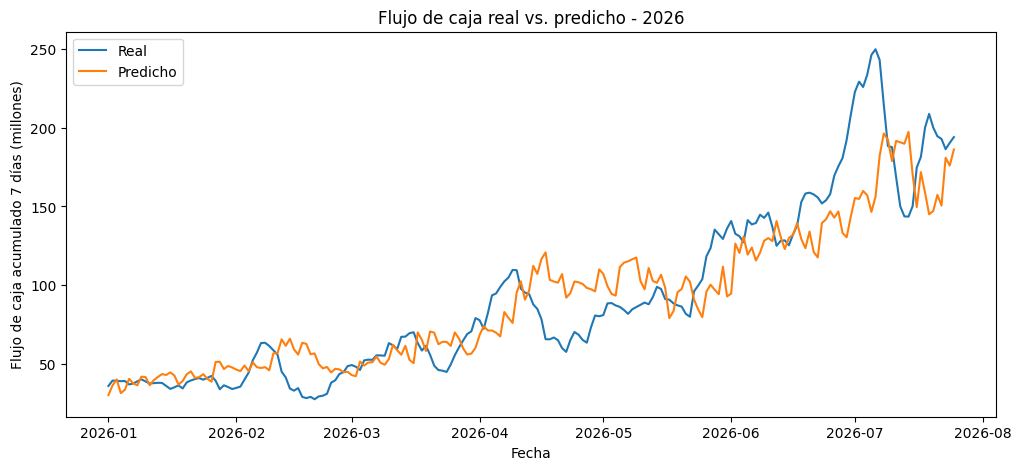

In [125]:
plt.figure(figsize=(12, 5))

plt.plot(
    resultados_pred["Fecha"],
    resultados_pred["Real"] / 1_000_000,
    label="Real"
)

plt.plot(
    resultados_pred["Fecha"],
    resultados_pred["Predicho"] / 1_000_000,
    label="Predicho"
)

plt.title("Flujo de caja real vs. predicho - 2026")
plt.xlabel("Fecha")
plt.ylabel("Flujo de caja acumulado 7 días (millones)")
plt.legend()
plt.show()

La comparación visual muestra que el modelo Ridge reproduce adecuadamente la tendencia general del flujo de caja durante 2026, aunque presenta una trayectoria más suavizada que los valores reales.

Las principales diferencias aparecen en períodos de movimientos extremos. El modelo tiende a sobreestimar algunas caídas y a subestimar los mayores picos de flujo de caja, especialmente durante julio. Esto indica que el modelo captura la dinámica general, pero tiene menor capacidad para anticipar variaciones extraordinarias.

### Análisis de errores

In [126]:
resultados_pred["Error"] = (
    resultados_pred["Real"] - resultados_pred["Predicho"]
)

resultados_pred["Error_Absoluto"] = abs(
    resultados_pred["Error"]
)

display(
    resultados_pred[
        ["Fecha", "Real", "Predicho", "Error", "Error_Absoluto"]
    ].head()
)

,Fecha,Real,Predicho,Error,Error_Absoluto
0,2026-01-01,36062336.0,3.028767e+07,5.774667e+06,5.774667e+06
1,2026-01-02,39487381.0,3.640704e+07,3.080339e+06,3.080339e+06
2,2026-01-03,39280996.0,4.021427e+07,-9.332692e+05,9.332692e+05
3,2026-01-04,39115798.0,3.153002e+07,7.585778e+06,7.585778e+06
4,2026-01-05,39206149.0,3.366157e+07,5.544578e+06,5.544578e+06


### Mayores errores de predicción

In [127]:
mayores_errores = (
    resultados_pred
    .sort_values("Error_Absoluto", ascending=False)
    .head(10)
)

display(
    mayores_errores[
        ["Fecha", "Real", "Predicho", "Error", "Error_Absoluto"]
    ]
)

,Fecha,Real,Predicho,Error,Error_Absoluto
185,2026-07-05,246106668.0,1.465090e+08,9.959763e+07,9.959763e+07
186,2026-07-06,249736041.0,1.561113e+08,9.362478e+07,9.362478e+07
184,2026-07-04,233661830.0,1.570457e+08,7.661616e+07,7.661616e+07
182,2026-07-02,229117762.0,1.547387e+08,7.437904e+07,7.437904e+07
181,2026-07-01,222664711.0,1.553157e+08,6.734902e+07,6.734902e+07
183,2026-07-03,225785672.0,1.598126e+08,6.597304e+07,6.597304e+07
180,2026-06-30,208098165.0,1.434576e+08,6.464059e+07,6.464059e+07
199,2026-07-19,208689690.0,1.449759e+08,6.371379e+07,6.371379e+07
179,2026-06-29,192244681.0,1.304415e+08,6.180315e+07,6.180315e+07
187,2026-07-07,242870348.0,1.820551e+08,6.081529e+07,6.081529e+07


Los mayores errores de predicción se concentran principalmente entre fines de junio y comienzos de julio de 2026. En estos períodos, el error es predominantemente positivo, indicando que el modelo subestima los niveles elevados de flujo de caja.

Este resultado es consistente con la visualización anterior: Ridge captura adecuadamente la tendencia general, pero presenta dificultades para anticipar movimientos extremos y picos de caja.

### Error por mes

In [128]:
resultados_pred["Mes"] = resultados_pred["Fecha"].dt.to_period("M").astype(str)

error_mensual = (
    resultados_pred
    .groupby("Mes")
    .agg(
        MAE=("Error_Absoluto", "mean"),
        Error_Medio=("Error", "mean")
    )
    .reset_index()
)

error_mensual["RMSE"] = (
    resultados_pred
    .groupby("Mes")["Error"]
    .apply(lambda x: np.sqrt(np.mean(x**2)))
    .values
)

error_mensual[["MAE", "Error_Medio", "RMSE"]] /= 1_000_000

display(error_mensual.round(2))

,Mes,MAE,Error_Medio,RMSE
0,2026-01,5.25,-3.32,6.84
1,2026-02,14.69,-10.20,18.10
2,2026-03,9.33,0.26,11.32
3,2026-04,25.68,-12.61,28.82
4,2026-05,18.89,-3.18,21.96
5,2026-06,21.43,19.56,27.29
6,2026-07,42.13,27.10,50.38


El análisis mensual confirma que el desempeño del modelo varía a lo largo del período de prueba.

Enero presenta el menor error, mientras que julio registra el mayor MAE y RMSE. Durante junio y julio, el error medio es positivo, indicando una tendencia del modelo a subestimar el flujo de caja. En cambio, durante febrero y abril se observa una tendencia a la sobreestimación.

Estos resultados muestran que el modelo captura razonablemente la dinámica general, pero su precisión disminuye en períodos con cambios más pronunciados en el nivel del flujo de caja.

## 15. Interpretabilidad del modelo


Dado que Ridge fue el modelo con mejor desempeño fuera de muestra, se analizan sus coeficientes para identificar qué variables tienen mayor influencia sobre la predicción del flujo de caja acumulado a 7 días.

Como las variables fueron estandarizadas dentro del `Pipeline`, la magnitud de los coeficientes puede compararse entre variables. Los coeficientes positivos se asocian con un aumento del flujo de caja predicho, mientras que los negativos se asocian con una disminución.

In [131]:
coeficientes_ridge = pd.DataFrame({
    "Variable": features,
    "Coeficiente": modelo_ridge_final.named_steps["ridge"].coef_
})

coeficientes_ridge["Importancia_Absoluta"] = (
    coeficientes_ridge["Coeficiente"].abs()
)

coeficientes_ridge = coeficientes_ridge.sort_values(
    "Importancia_Absoluta",
    ascending=False
)

display(coeficientes_ridge)

,Variable,Coeficiente,Importancia_Absoluta
7,Flujo_Media7,1.940543e+07,1.940543e+07
8,Ventas_Media30,1.547875e+07,1.547875e+07
4,Flujo_Lag1,1.178347e+07,1.178347e+07
9,Flujo_Media30,1.007441e+07,1.007441e+07
5,Flujo_Lag7,6.362949e+06,6.362949e+06
3,Ventas_Lag7,-2.807863e+06,2.807863e+06
1,Mes,-4.514126e+05,4.514126e+05
0,Dia_Semana,-3.110748e+05,3.110748e+05
2,Ventas_Lag1,2.682681e+05,2.682681e+05
6,Ventas_Media7,2.223990e+05,2.223990e+05


Los coeficientes del modelo Ridge muestran que las variables relacionadas con el comportamiento reciente del flujo de caja tienen la mayor influencia sobre las predicciones.

`Flujo_Media7` presenta el coeficiente de mayor magnitud, seguido por `Ventas_Media30`, `Flujo_Lag1` y `Flujo_Media30`. Esto indica que el modelo utiliza principalmente la dinámica reciente del flujo de caja y el nivel promedio de ventas para estimar el flujo acumulado de los próximos 7 días.

Algunas variables presentan coeficientes negativos, como `Ventas_Lag7`. Estos coeficientes no deben interpretarse como relaciones causales, ya que varias variables temporales están correlacionadas entre sí y Ridge distribuye sus efectos mediante la regularización.

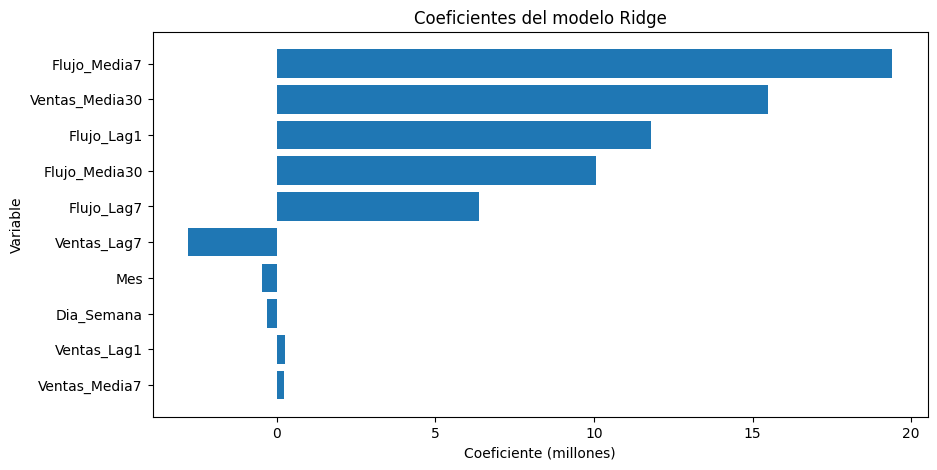

In [132]:
plt.figure(figsize=(10, 5))

plt.barh(
    coeficientes_ridge["Variable"],
    coeficientes_ridge["Coeficiente"] / 1_000_000
)

plt.xlabel("Coeficiente (millones)")
plt.ylabel("Variable")
plt.title("Coeficientes del modelo Ridge")

plt.gca().invert_yaxis()
plt.show()

La visualización de los coeficientes confirma que el modelo Ridge depende principalmente del comportamiento reciente del flujo de caja y del nivel promedio de ventas.

Las variables `Flujo_Media7`, `Ventas_Media30`, `Flujo_Lag1` y `Flujo_Media30` presentan los coeficientes de mayor magnitud. En cambio, las variables de calendario y algunas variables de ventas recientes tienen una influencia considerablemente menor dentro del modelo.

Los signos de los coeficientes representan asociaciones dentro del modelo y no deben interpretarse como relaciones causales.